

---

### **1. Objective**
- **SVM**:  
  **Maximizes the margin** between classes by finding the optimal hyperplane.  
  **Illustration**:  
  ```
  Best Line (Max Margin):  
  Red Points (Apples) →  ↑ Margin ↑ ← Blue Points (Oranges)  
  ```  
  Focuses on **support vectors** (closest points to the boundary).

- **Logistic Regression**:  
  **Models the probability** of a class using a logistic function.  
  **Illustration**:  
  ```
  Probability Curve:  
  Red Points (Apples) →  S-shaped curve → Blue Points (Oranges)  
  ```  
  Fits a curve to estimate the likelihood of class membership.

---

### **2. Decision Boundary**
- **SVM**:  
  - Finds the **widest possible gap** (margin) between classes.  
  - Only **support vectors** (critical points) influence the boundary.  
  - **Example**: For concentric circles, SVM with RBF kernel maps data to 3D to separate them.  

- **Logistic Regression**:  
  - Fits a **linear or non-linear boundary** (depending on features) based on all data points.  
  - No explicit margin maximization; focuses on **probability thresholds**.  
  - **Example**: For concentric circles, it would fail unless you engineer non-linear features (e.g., polynomial terms).

---

### **3. Loss Function**
- **SVM**:  
  - Uses **hinge loss**: Penalizes points that are on the wrong side of the margin.  
  - Focuses only on maximizing the margin and classifying support vectors correctly.  
  - **Insensitive to points far from the boundary**.  

- **Logistic Regression**:  
  - Uses **log loss**: Penalizes all points based on their predicted probability.  
  - Considers **all data points** to model class probabilities.  
  - **Sensitive to outliers** because it tries to fit all points.

---

### **4. Handling Non-Linear Data**
- **SVM**:  
  - Uses **kernels** (e.g., RBF, polynomial) to map data into higher dimensions.  
  - **Example**: Transforms 2D circles into 3D bowl shapes where a flat plane separates them.  

- **Logistic Regression**:  
  - Requires **manual feature engineering** (e.g., polynomial features) to handle non-linearity.  
  - **Example**: For circles, you’d add $ x^2 + y^2 $ as a feature to create a linear boundary in transformed space.

---

### **5. Output**
- **SVM**:  
  - Outputs a **class label** (e.g., "Red" or "Blue").  
  - Does **not directly provide probabilities** (though some implementations estimate them).  

- **Logistic Regression**:  
  - Outputs **probabilities** (e.g., 70% chance of "Red," 30% chance of "Blue").  
  - Provides interpretable confidence scores.

---

### **Key Difference Summary**
| **Aspect**               | **SVM**                          | **Logistic Regression**          |
|--------------------------|----------------------------------|-----------------------------------|
| **Goal**                 | Maximize margin between classes  | Model class probabilities         |
| **Boundary Focus**       | Support vectors only             | All data points                   |
| **Loss Function**        | Hinge loss                       | Log loss                          |
| **Non-Linearity**        | Kernel trick (automatic)         | Requires feature engineering      |
| **Output**               | Class label                      | Probability score                 |
| **Outlier Sensitivity**  | Less sensitive (ignores far points) | More sensitive (uses all points) |

---

### **Real-World Analogy**
- **SVM** is like a **fencing coach** who builds a fence (decision boundary) that keeps sheep (data points) as far apart as possible, focusing only on the closest ones (support vectors).  
- **Logistic Regression** is like a **weather forecaster** who estimates the probability of rain (class membership) by analyzing all historical weather data points.  

Both separate classes, but **SVM prioritizes margin maximization**, while **Logistic Regression prioritizes modeling probabilities**.

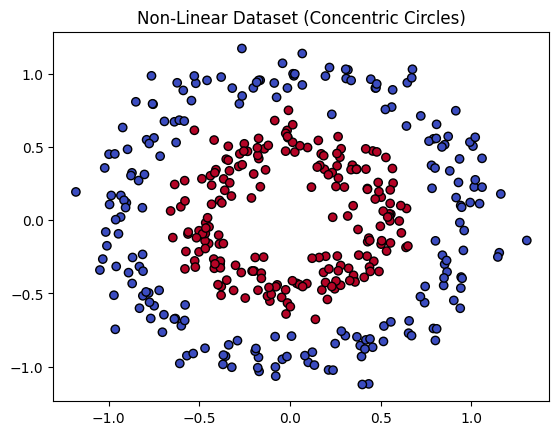

Linear SVM Accuracy: 0.45
RBF SVM Accuracy: 0.99
Logistic Regression Accuracy: 0.45


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Generate non-linear dataset
X, y = make_circles(n_samples=400, noise=0.1, factor=0.5, random_state=42)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Plot dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Non-Linear Dataset (Concentric Circles)")
plt.show()

# Train models
models = {
    "Linear SVM": make_pipeline(StandardScaler(), SVC(kernel='linear')),
    "RBF SVM": make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale')),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression())
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")



---

### **1. Primal Optimization Problem (Linear SVM)**
**Goal**: Find a hyperplane $ w^T x + b = 0 $ that separates classes with maximum margin.  
**Variables**:
- $ w $: Weight vector (normal to the hyperplane).  
- $ b $: Bias term (shifts the hyperplane).  
- $ x_i $: Input features.  
- $ y_i \in \{-1, +1\} $: Class labels.  

**Hard-Margin SVM** (no misclassifications):  
$$
\min_{w, b} \frac{1}{2} \|w\|^2 \quad \text{subject to } y_i(w^T x_i + b) \geq 1 \quad \forall i
$$  
**Why?**  
- $ \|w\| $: Controls the margin width ($ \text{Margin} = \frac{2}{\|w\|} $).  
- $ y_i(w^T x_i + b) \geq 1 $: Ensures correct classification with margin.  

**Soft-Margin SVM** (allows misclassifications):  
$$
\min_{w, b, \xi_i} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i \quad \text{subject to } y_i(w^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$  
- $ C $: Regularization parameter (trade-off between margin and misclassifications).  
- $ \xi_i $: Slack variables (penalizes points within or on the wrong side of the margin).

---

### **2. Dual Formulation (Lagrange Multipliers)**
To solve the constrained optimization problem, we use **Lagrange multipliers**.  
**Lagrangian**:  
$$
\mathcal{L}(w, b, \alpha) = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \xi_i - \sum_{i=1}^n \alpha_i [y_i(w^T x_i + b) - 1 + \xi_i] - \sum_{i=1}^n \mu_i \xi_i
$$  
**KKT Conditions**:  
1. **Stationarity**:  
   $$
   \frac{\partial \mathcal{L}}{\partial w} = 0 \Rightarrow w = \sum_{i=1}^n \alpha_i y_i x_i
   $$  
   $$
   \frac{\partial \mathcal{L}}{\partial b} = 0 \Rightarrow \sum_{i=1}^n \alpha_i y_i = 0
   $$  
2. **Complementary Slackness**:  
   $$
   \alpha_i \left[ y_i(w^T x_i + b) - 1 + \xi_i \right] = 0, \quad \mu_i \xi_i = 0
   $$  

**Dual Problem** (simplified):  
$$
\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j x_i^T x_j
$$  
$$
\text{subject to } 0 \leq \alpha_i \leq C, \quad \sum_{i=1}^n \alpha_i y_i = 0
$$  
- **Key Insight**: The solution depends only on **dot products** $ x_i^T x_j $, enabling the **kernel trick**.

---

### **3. Kernel Trick: Non-Linear SVM**
When data is not linearly separable, we use a **kernel function** $ K(x_i, x_j) $ to implicitly map data to a higher-dimensional space.  
**Kernel Function**:  
$$
K(x_i, x_j) = \phi(x_i)^T \phi(x_j)
$$  
- $ \phi(x) $: Implicit feature mapping (e.g., polynomial, RBF).  

**Common Kernels**:
1. **Linear**: $ K(x_i, x_j) = x_i^T x_j $  
2. **Polynomial**: $ K(x_i, x_j) = (x_i^T x_j + c)^d $  
3. **RBF (Gaussian)**:  
   $$
   K(x_i, x_j) = \exp\left( -\gamma \|x_i - x_j\|^2 \right)
   $$  
   - $ \gamma $: Controls the influence of each training example.  

**Dual Problem with Kernel**:  
$$
\max_{\alpha} \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(x_i, x_j)
$$  
- Replaces dot products $ x_i^T x_j $ with $ K(x_i, x_j) $.  

**Decision Function**:  
$$
f(x) = \text{sign}\left( \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b \right)
$$  
- Only **support vectors** (points with $ \alpha_i > 0 $) contribute to the decision.

---

### **4. Solving the Dual Problem: Quadratic Programming**
The dual problem is a **convex quadratic optimization problem**.  
**Objective**:  
$$
\min_{\alpha} \frac{1}{2} \alpha^T Q \alpha - \mathbf{1}^T \alpha
$$  
$$
\text{subject to } y^T \alpha = 0, \quad 0 \leq \alpha_i \leq C
$$  
- $ Q \in \mathbb{R}^{n \times n} $: Matrix where $ Q_{ij} = y_i y_j K(x_i, x_j) $.  

**Algorithms**:
- **Sequential Minimal Optimization (SMO)**: Breaks the problem into 2D subproblems solvable analytically.  
- **LibSVM**: Library implementing efficient SVM solvers.

---

### **5. Role of Parameters**
- **$ C $**:  
  - Large $ C $: Prioritizes minimizing classification errors (narrow margin).  
  - Small $ C $: Prioritizes maximizing margin (tolerates misclassifications).  
- **$ \gamma $** (for RBF kernel):  
  - Large $ \gamma $: High influence of individual points (overfitting).  
  - Small $ \gamma $: Smooth decision boundary (underfitting).  

---

### **6. Geometric Interpretation**
- **Support Vectors**: Points with $ \alpha_i > 0 $ lying on or inside the margin.  
- **Margin Width**:  
  $$
  \text{Margin} = \frac{2}{\|w\|} = \frac{2}{\sqrt{\sum_{i=1}^n \sum_{j=1}^n \alpha_i \alpha_j y_i y_j K(x_i, x_j)}}
  $$  
- **Decision Boundary**:  
  $$
  w^T \phi(x) + b = \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b = 0
  $$

---

### **7. Comparison with Logistic Regression**
- **Objective**:  
  - **SVM**: Maximizes margin (hinge loss).  
  - **Logistic Regression**: Minimizes log loss to model probabilities.  
- **Optimization**:  
  - **SVM**: Constrained quadratic optimization (dual form).  
  - **Logistic Regression**: Unconstrained convex optimization.  
- **Non-Linearity**:  
  - **SVM**: Uses kernel trick (implicit mapping).  
  - **Logistic Regression**: Requires explicit feature engineering (e.g., polynomial terms).  

---

### **8. Example: RBF Kernel on Make-Circles Dataset**
For concentric circles:  
- **Input Space**: 2D (non-linearly separable).  
- **Kernel Mapping**:  
  $$
  \phi(x) = \exp(-\gamma (x_1^2 + x_2^2)) \quad \text{(maps to 3D bowl shape)}
  $$  
- **Decision Boundary**: A flat plane in 3D separates the classes.  

**Math Behind It**:  
$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2) \Rightarrow \text{Measures similarity between points}
$$  
- Points close to each other in input space have high similarity (large $ K $), enabling separation in feature space.

---

### **Key Equations Summary**
| Equation | Purpose |
|---------|---------|
| $ \min_{w, b} \frac{1}{2} \|w\|^2 $ | Margin maximization (primal) |
| $ y_i(w^T x_i + b) \geq 1 $ | Classification constraint |
| $ \max_{\alpha} \sum \alpha_i - \frac{1}{2} \sum \sum \alpha_i \alpha_j y_i y_j K(x_i, x_j) $ | Dual problem with kernel |
| $ f(x) = \sum \alpha_i y_i K(x_i, x) + b $ | Decision function |
| $ \text{Margin} = \frac{2}{\|w\|} $ | Margin width |

This mathematical framework explains why SVM with RBF kernels outperforms linear models on non-linear datasets like `make_circles`. 🚀